**Main imports**

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from IPython import display as disp

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

**Import dataset**

In [2]:
# helper function to make getting another batch of data easier
def cycle(iterable):
    while True:
        for x in iterable:
            yield x

class_names = ['apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle','bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle','chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup','dinosaur','dolphin','elephant','flatfish','forest','fox','girl','hamster','house','kangaroo','computer_keyboard','lamp','lawn_mower','leopard','lion','lizard','lobster','man','maple_tree','motorcycle','mountain','mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree','plain','plate','poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket','rose','sea','seal','shark','shrew','skunk','skyscraper','snail','snake','spider','squirrel','streetcar','sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor','train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm',]

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR100('data', train=True, download=True, transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])),
    batch_size=64, drop_last=True)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.CIFAR100('data', train=False, download=True, transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])),
    batch_size=64, drop_last=True)

train_iterator = iter(cycle(train_loader))
test_iterator = iter(cycle(test_loader))

print(f'> Size of training dataset {len(train_loader.dataset)}')
print(f'> Size of test dataset {len(test_loader.dataset)}')

100%|██████████| 169M/169M [00:04<00:00, 41.6MB/s]


Extracting data/cifar-100-python.tar.gz to data
Files already downloaded and verified
> Size of training dataset 50000
> Size of test dataset 10000


**View some of the test dataset**

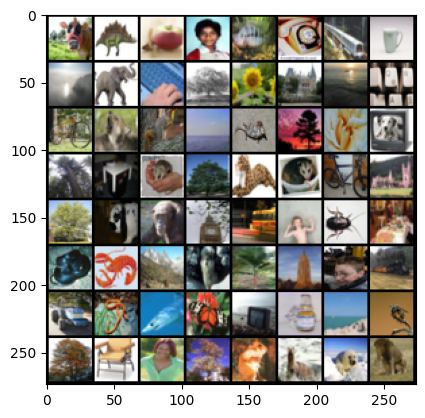

In [3]:
# let's view some of the training data
plt.rcParams['figure.dpi'] = 100
x,t = next(train_iterator)
x,t = x.to(device), t.to(device)
plt.imshow(torchvision.utils.make_grid(x).cpu().numpy().transpose(1, 2, 0), cmap=plt.cm.binary)
plt.show()

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.7 MB/s eta 0:00:00


This cell implements a **Deep Convolutional Generative Adversarial Network (DCGAN)** using convolutional layers for both the Generator and Discriminator to generate realistic images. It employs **Optuna** for hyperparameter tuning to optimize learning rate and momentum, ensuring the best training performance.

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torchvision
# import matplotlib.pyplot as plt
# from IPython import display as disp
# import optuna

# # setting up device for gpu if available, otherwise cpu
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # define the generator model
# class Generator(nn.Module):
#     def __init__(self, params):
#         super(Generator, self).__init__()
#         self.main = nn.Sequential(
#             nn.ConvTranspose2d(params['n_latent'], 192, 4, 1, 0, bias=False),
#             nn.BatchNorm2d(192),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(192, 96, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(96),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(96, 48, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(48),
#             nn.ReLU(True),
#             nn.ConvTranspose2d(48, params['n_channels'], 4, 2, 1, bias=False),
#             nn.Tanh()
#         )

#     def forward(self, input):
#         return self.main(input)

# # define the discriminator model
# class Discriminator(nn.Module):
#     def __init__(self, params):
#         super(Discriminator, self).__init__()
#         self.main = nn.Sequential(
#             nn.Conv2d(params['n_channels'], 32, 4, 2, 1, bias=False),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(32, 64, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(64),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(64, 128, 4, 2, 1, bias=False),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Conv2d(128, 1, 4, 1, 0, bias=False),
#             nn.Sigmoid()
#         )

#     def forward(self, input):
#         return self.main(input).view(-1)

# # define the objective function for optuna hyperparameter tuning
# def objective(trial):
#     params = {
#         'batch_size': 64,
#         'n_channels': 3,
#         'n_latent': 100,
#         'lr': trial.suggest_loguniform('lr', 1e-5, 1e-3),
#         'beta1': trial.suggest_uniform('beta1', 0.3, 0.7)
#     }

#     G = Generator(params).to(device)
#     D = Discriminator(params).to(device)

#     optimizer_G = torch.optim.Adam(G.parameters(), lr=params['lr'], betas=(params['beta1'], 0.999))
#     optimizer_D = torch.optim.Adam(D.parameters(), lr=params['lr'], betas=(params['beta1'], 0.999))

#     criterion = nn.BCELoss()

#     # quick training loop just for tuning the hyperparameters
#     for epoch in range(2):  # just 2 epochs to keep it fast
#         noise = torch.randn(params['batch_size'], params['n_latent'], 1, 1, device=device)
#         real_labels = torch.ones(params['batch_size'], device=device)
#         fake_labels = torch.zeros(params['batch_size'], device=device)

#         # train the generator
#         optimizer_G.zero_grad()
#         fake_images = G(noise)
#         outputs = D(fake_images)
#         g_loss = criterion(outputs, real_labels)
#         g_loss.backward()
#         optimizer_G.step()

#         # train the discriminator
#         optimizer_D.zero_grad()
#         outputs_real = D(fake_images.detach())
#         d_loss_real = criterion(outputs_real, fake_labels)
#         d_loss_real.backward()
#         optimizer_D.step()

#     return g_loss.item() + d_loss_real.item()

# # run the optuna study to find the best hyperparameters
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=20)

# # print out the best hyperparameters found
# best_params = study.best_params
# print(f'Best Hyperparameters: {best_params}')

# # set up the final model with the best hyperparameters
# params = {
#     'batch_size': 64,
#     'n_channels': 3,
#     'n_latent': 100,
#     'lr': best_params['lr'],
#     'beta1': best_params['beta1']
# }

# # initialize the generator and discriminator with the best params
# G = Generator(params).to(device)
# D = Discriminator(params).to(device)

# # count total parameters in both models
# total_params = sum(p.numel() for p in G.parameters()) + sum(p.numel() for p in D.parameters())
# print(f'> Number of model parameters {total_params}')
# if total_params > 1000000:
#     print("> Warning: you have gone over your parameter budget and will have a grade penalty!")

# # set up the optimizers for both generator and discriminator
# optimizer_G = torch.optim.Adam(G.parameters(), lr=params['lr'], betas=(params['beta1'], 0.999))
# optimizer_D = torch.optim.Adam(D.parameters(), lr=params['lr'], betas=(params['beta1'], 0.999))

# # define the loss function for training
# criterion = nn.BCELoss()


This cell implements a **Deep Convolutional Generative Adversarial Network (DCGAN)** with predefined architectures for the Generator and Discriminator and uses Binary Cross-Entropy Loss for training. It hardcodes the **best hyperparameters (learning rate = 0.0004 and beta1 = 0.7)** found from the previous Optuna optimization cell to finalize the model setup.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from IPython import display as disp
import optuna

# setting up device for gpu if available, else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# generator model
class Generator(nn.Module):
    def __init__(self, params):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(params['n_latent'], 192, 4, 1, 0, bias=False),
            nn.BatchNorm2d(192),
            nn.ReLU(True),
            nn.ConvTranspose2d(192, 96, 4, 2, 1, bias=False),
            nn.BatchNorm2d(96),
            nn.ReLU(True),
            nn.ConvTranspose2d(96, 48, 4, 2, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(True),
            nn.ConvTranspose2d(48, params['n_channels'], 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# discriminator model
class Discriminator(nn.Module):
    def __init__(self, params):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(params['n_channels'], 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

# using best hyperparameters from previous tuning
best_params = {'lr': 0.0004, 'beta1': 0.7}
print(f'Best Hyperparameters: {best_params}')

# defining parameters for the models
params = {
    'batch_size': 64,
    'n_channels': 3,
    'n_latent': 100,
    'lr': best_params['lr'],
    'beta1': best_params['beta1']
}

# initializing the generator and discriminator
G = Generator(params).to(device)
D = Discriminator(params).to(device)

# calculating total number of parameters
total_params = sum(p.numel() for p in G.parameters()) + sum(p.numel() for p in D.parameters())
print(f'> Number of model parameters {total_params}')
if total_params > 1000000:
    print("> Warning: you have gone over your parameter budget and will have a grade penalty!")

# setting up optimizers for both generator and discriminator
optimizer_G = torch.optim.Adam(G.parameters(), lr=params['lr'], betas=(params['beta1'], 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=params['lr'], betas=(params['beta1'], 0.999))

# defining the loss function
criterion = nn.BCELoss()


Best Hyperparameters: {'lr': 0.0004, 'beta1': 0.7}
> Number of model parameters 846624


**Main training loop**

Steps 50000: D Loss: 0.4762, G Loss: 2.9243


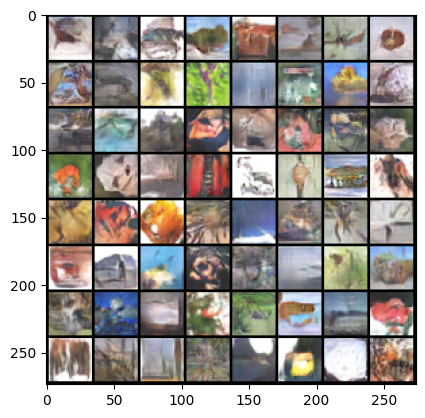

In [7]:
steps = 0

while steps < 50000:
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Real and fake labels
        real_labels = torch.full((batch_size,), 1., device=device)
        fake_labels = torch.full((batch_size,), 0., device=device)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_output = D(real_imgs)
        d_loss_real = criterion(real_output, real_labels)

        z = torch.randn(batch_size, params['n_latent'], 1, 1, device=device)
        fake_imgs = G(z)
        fake_output = D(fake_imgs.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        output = D(fake_imgs)
        g_loss = criterion(output, real_labels)  # Try to fool the discriminator
        g_loss.backward()
        optimizer_G.step()

        steps += 1

        if steps % 1000 == 0:
            print(f'Steps {steps}: D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}')
            G.eval()
            with torch.no_grad():
                z = torch.randn(params['batch_size'], params['n_latent'], 1, 1).to(device)
                samples = G(z).cpu()
                plt.imshow(torchvision.utils.make_grid(samples, nrow=8, normalize=True).numpy().transpose(1, 2, 0))
                plt.show()
                disp.clear_output(wait=True)
            G.train()


**Latent interpolations**

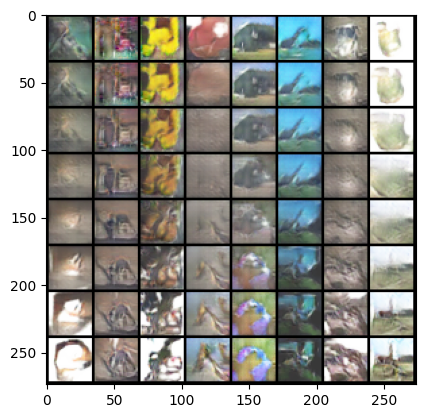

In [8]:
col_size = int(np.sqrt(params['batch_size']))

# pick two sets of latent vectors for interpolation
z0 = z[0:col_size].repeat(col_size, 1, 1, 1)  # top row latent vectors
z1 = z[params['batch_size'] - col_size:].repeat(col_size, 1, 1, 1)  # bottom row latent vectors

# interpolate linearly between z0 and z1
t = torch.linspace(0, 1, col_size).unsqueeze(1).repeat(1, col_size).view(params['batch_size'], 1, 1, 1).to(device)
lerp_z = (1 - t) * z0 + t * z1

# generate images from the interpolated latent vectors
lerp_g = G(lerp_z)

# visualize the generated images
plt.rcParams['figure.dpi'] = 100
plt.grid(False)
plt.imshow(torchvision.utils.make_grid(lerp_g, nrow=col_size, normalize=True).cpu().numpy().transpose(1, 2, 0))
plt.show()

**FID scores**

Evaluate the FID from 10k of your model samples (do not sample more than this) and compare it against the 10k test images. Calculating FID is somewhat involved, so we use a library for it. It can take a few minutes to evaluate. Lower FID scores are better.

In [9]:
%%capture
!pip install clean-fid
import os
from cleanfid import fid
from torchvision.utils import save_image

In [10]:
import os
from torchvision.utils import save_image

# Define directories
real_images_dir = 'real_images'
generated_images_dir = 'generated_images'
num_samples = 10000  # Do not change

# Create/clean the directories
def setup_directory(directory):
    if os.path.exists(directory):
        os.system(f'rm -r {directory}')  # Remove existing data
    os.makedirs(directory)

setup_directory(real_images_dir)
setup_directory(generated_images_dir)

# Generate and save 10k model samples
num_generated = 0
while num_generated < num_samples:
    z = torch.randn(params['batch_size'], params['n_latent'], 1, 1).to(device)
    samples_batch = G(z).cpu().detach()  # Use Generator to create samples

    for image in samples_batch:
        if num_generated >= num_samples:
            break
        save_image(image, os.path.join(generated_images_dir, f"gen_img_{num_generated}.png"))
        num_generated += 1

# Save 10k images from the CIFAR-100 test dataset
num_saved_real = 0
while num_saved_real < num_samples:
    real_samples_batch, _ = next(test_iterator)
    for image in real_samples_batch:
        if num_saved_real >= num_samples:
            break
        save_image(image, os.path.join(real_images_dir, f"real_img_{num_saved_real}.png"))
        num_saved_real += 1


In [11]:
# compute FID
score = fid.compute_fid(real_images_dir, generated_images_dir, mode="clean")
print(f"FID score: {score}")

compute FID between two folders


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Found 10000 images in the folder real_images


FID real_images : 100%|██████████| 313/313 [01:16<00:00,  4.08it/s]


Found 10000 images in the folder generated_images


FID generated_images : 100%|██████████| 313/313 [01:13<00:00,  4.28it/s]


FID score: 55.58222464985704
